In [9]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.linear_model import ElasticNet

from catboost import CatBoostRegressor


import optuna

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [10]:
import os
print(os.listdir("crop-yield-prediction-dataset"))

['temp.csv', 'pesticides.csv', 'yield_df.csv', 'rainfall.csv', 'yield.csv']


In [11]:

df = pd.read_csv("crop-yield-prediction-dataset/yield_df.csv")

target = "hg/ha_yield"

cat_cols = ["soil_type", "crop_name", "water_supply", "fertilizer_usage"]
num_cols = ["temperature", "rainfall", "soil_ph"]

print("Shape:", df.shape)
df.head()

Shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [12]:
print(df.columns)

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


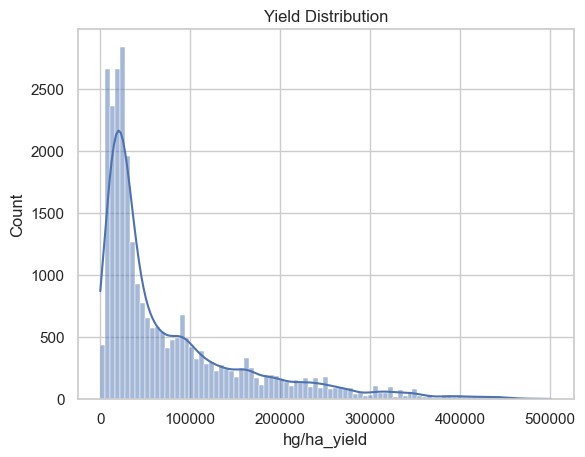

In [13]:
plt.figure()
sns.histplot(df[target], kde=True)
plt.title("Yield Distribution")
plt.show()

In [14]:
print(df.columns)

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [18]:
df["temp_rain"] = df["avg_temp"] * df["average_rain_fall_mm_per_year"]
df["rain_log"] = np.log1p(df["average_rain_fall_mm_per_year"])
df["temp_sq"] = df["avg_temp"] ** 2

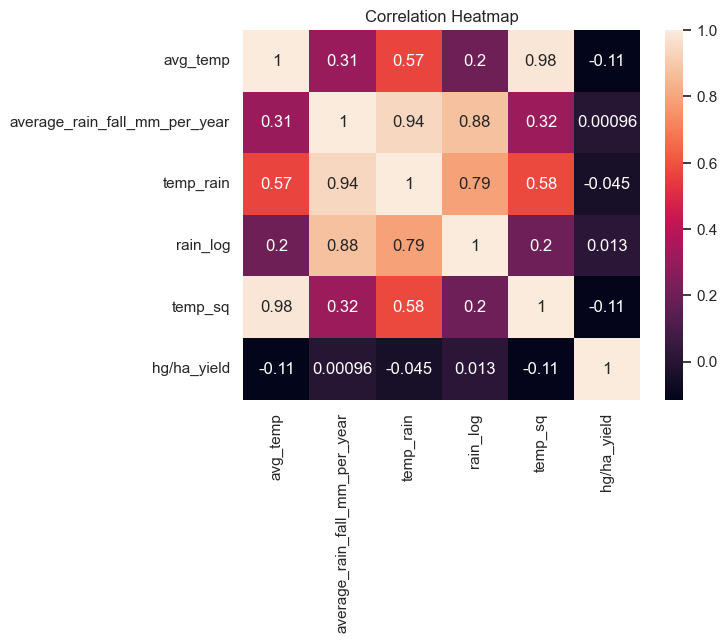

In [19]:
plt.figure()

corr_cols = ["avg_temp", "average_rain_fall_mm_per_year", "temp_rain", "rain_log", "temp_sq", target]
sns.heatmap(df[corr_cols].corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

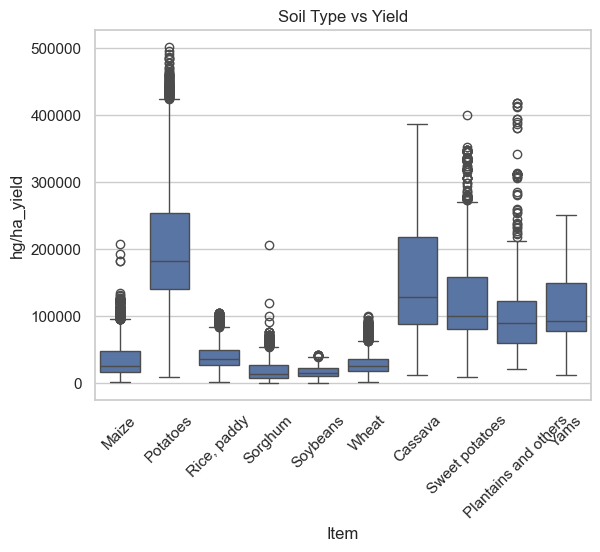

In [21]:
plt.figure()
sns.boxplot(x="Item", y="hg/ha_yield", data=df)
plt.xticks(rotation=90)
plt.title("Soil Type vs Yield")
plt.xticks(rotation=45)
plt.show()

In [24]:
cat_cols = ["Area", "Item"]
num_cols = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
target = "hg/ha_yield"

features = cat_cols + num_cols + ["temp_rain", "rain_log", "temp_sq"]

X = df[features].copy()
y = df[target]

y_log = np.log1p(y)
print(X.head())
print(y.head())

      Area         Item  Year  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990                         1485.0   
1  Albania     Potatoes  1990                         1485.0   
2  Albania  Rice, paddy  1990                         1485.0   
3  Albania      Sorghum  1990                         1485.0   
4  Albania     Soybeans  1990                         1485.0   

   pesticides_tonnes  avg_temp  temp_rain  rain_log   temp_sq  
0              121.0     16.37   24309.45  7.303843  267.9769  
1              121.0     16.37   24309.45  7.303843  267.9769  
2              121.0     16.37   24309.45  7.303843  267.9769  
3              121.0     16.37   24309.45  7.303843  267.9769  
4              121.0     16.37   24309.45  7.303843  267.9769  
0    36613
1    66667
2    23333
3    12500
4     7000
Name: hg/ha_yield, dtype: int64


In [25]:
X_encoded = X.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [27]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 2),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }
    scores = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)  # reduce CV folds
    for train_idx, val_idx in kf.split(X_encoded):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_encoded.iloc[train_idx],
            y_log.iloc[train_idx],
            eval_set=[(X_encoded.iloc[val_idx], y_log.iloc[val_idx])],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(30, verbose=False)]  # faster stopping
        )
        preds = np.expm1(model.predict(X_encoded.iloc[val_idx]))
        scores.append(r2_score(y.iloc[val_idx], preds))
    return np.mean(scores)

In [28]:
X_catboost = X.copy()
for col in cat_cols:
    X_catboost[col] = X_catboost[col].astype(str)

In [30]:
# Reduce CatBoost/XGB/LGBM iterations
ccat_model = CatBoostRegressor(
    iterations=800,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    random_state=42,
    verbose=False,
    task_type='CPU'
)

cat_model.fit(X_catboost, y_log, cat_features=cat_cols)

CatBoostRegressor(depth=8, iterations=800, learning_rate=0.03, loss_function='RMSE', random_state=42, task_type='CPU', verbose=False)

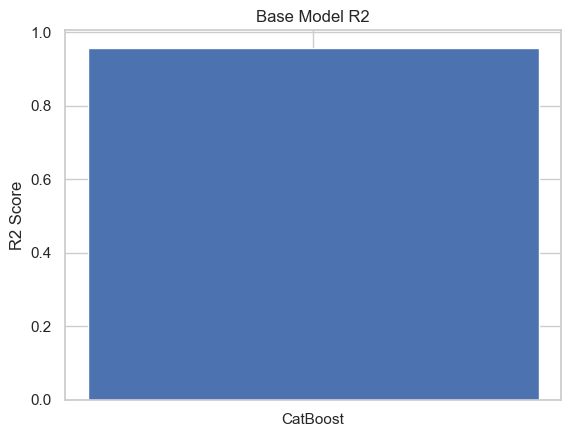

In [33]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

model_map = {
    "CatBoost": cat_model,
    
    
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = {}

for name, model in model_map.items():
    meta_preds = np.zeros(len(X))  # store fold predictions

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        X_tr_enc, X_val_enc = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y.iloc[val_idx]

        if name == "CatBoost":
            model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=False)
            preds = np.expm1(model.predict(X_val))
        else:
            model.fit(X_tr_enc, y_tr)
            preds = np.expm1(model.predict(X_val_enc))

        meta_preds[val_idx] = preds

    r2_scores[name] = r2_score(y, meta_preds)

# Plot
import matplotlib.pyplot as plt
plt.bar(r2_scores.keys(), r2_scores.values())
plt.ylabel("R2 Score")
plt.title("Base Model R2")
plt.show()

CatBoost Accuracy (%): 85.44082086532572


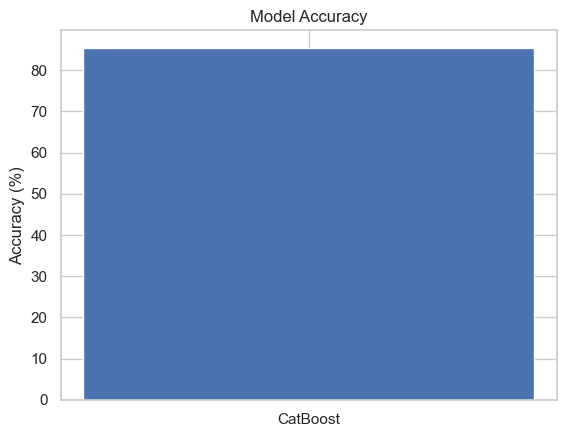

In [35]:
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

accuracies = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

preds = np.zeros(len(y))

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr = y_log.iloc[train_idx]

    cat_model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=False)
    preds[val_idx] = np.expm1(cat_model.predict(X_val))

mape = np.mean(np.abs((y - preds) / (y + 1e-6))) * 100
accuracy = 100 - mape

print("CatBoost Accuracy (%):", accuracy)

plt.figure()
plt.bar(["CatBoost"], [accuracy])
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy")
plt.show()

In [36]:
import joblib
joblib.dump(cat_model,"yield_model.pkl")

['yield_model.pkl']

In [38]:
cat_model.fit(X, y_log, cat_features=cat_cols, verbose=False)

preds = np.expm1(cat_model.predict(X))

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 8273.493273667076
R2 Score: 0.9620966438312997


In [39]:
import joblib
joblib.dump(cat_model, "yield_model.pkl")
print("yield model saved")

yield model saved


In [40]:
meta_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
meta_model.fit(meta_features, y)

stack_preds = meta_model.predict(meta_features)

r2 = r2_score(y, stack_preds)
mae = mean_absolute_error(y, stack_preds)
mape = np.mean(np.abs((y - stack_preds) / (y + 1e-6))) * 100
accuracy = 100 - mape

print("R2:", r2)
print("MAE:", mae)
print("Accuracy:", accuracy)

R2: 0.964371423104847
MAE: 8236.253388063618
Accuracy: 86.47821997889372


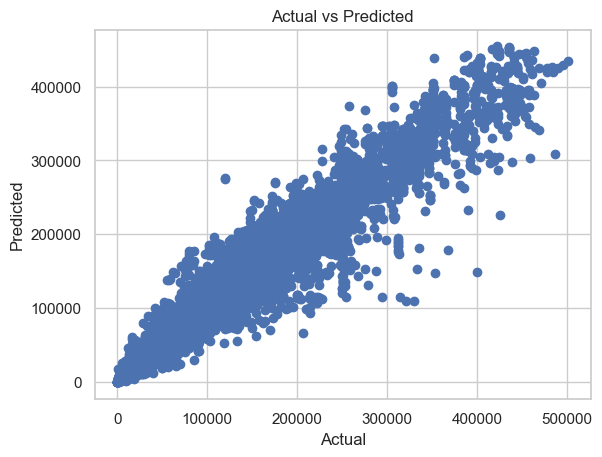

In [41]:
plt.figure()
plt.scatter(y, stack_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

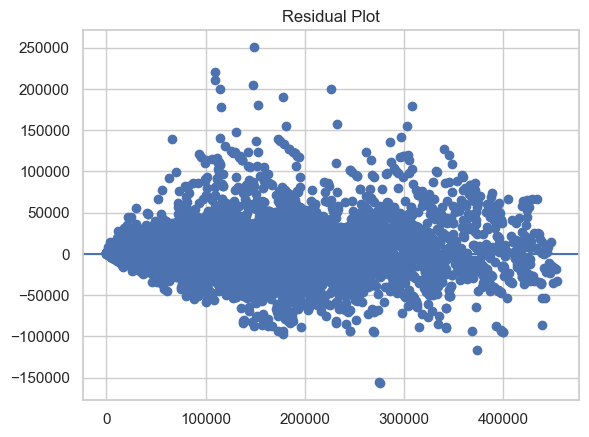

In [42]:
residuals = y - stack_preds

plt.figure()
plt.scatter(stack_preds, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

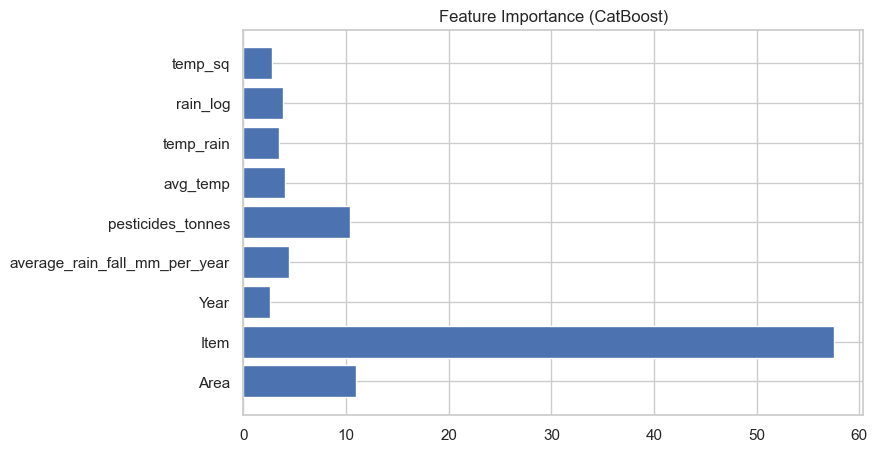

In [44]:
import matplotlib.pyplot as plt

importances = cat_model.get_feature_importance()
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.barh(feature_names, importances)
plt.title("Feature Importance (CatBoost)")
plt.show()

In [46]:
import joblib
joblib.dump(cat_model, "yield_model.pkl")
print("✅ Yield model saved")

✅ Yield model saved


In [47]:
def predict_yield(input_df):
    df = input_df.copy()

    # Feature engineering
    df["temp_rain"] = df["avg_temp"] * df["average_rain_fall_mm_per_year"]
    df["rain_log"] = np.log1p(df["average_rain_fall_mm_per_year"])
    df["temp_sq"] = df["avg_temp"] ** 2

    # Keep same feature order
    df = df[features]

    # Prediction
    pred_log = cat_model.predict(df)
    pred = np.expm1(pred_log)

    return pred

In [48]:
def predict_yield(input_df):
    df = input_df.copy()

    # 1. Feature engineering (Must be done before reordering)
    df["temp_rain"] = df["temperature"] * df["rainfall"]
    df["ph_sq"] = df["soil_ph"] ** 2
    df["rain_log"] = np.log1p(df["rainfall"])
    df["temp_sq"] = df["temperature"] ** 2

    # 2. Match the exact feature order used during training
    # This is a common source of silent errors!
    df = df[features]

    # 3. Prepare CatBoost DataFrame
    df_cat = df.copy()
    for col in cat_cols:
        # Force conversion to string and strip any trailing .0 from floats
        df_cat[col] = df_cat[col].astype(float).astype(int).astype(str) if df_cat[col].dtype != object else df_cat[col].astype(str)

    # 4. Label encode for LGBM/XGB
    df_enc = df.copy()
    for col in cat_cols:
        le = label_encoders[col]
        # Handle unseen labels by mapping to a default if necessary
        df_enc[col] = df_enc[col].apply(lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1)

    # 5. Base predictions
    p1 = np.expm1(cat_model.predict(df_cat))
    p2 = np.expm1(lgb_model.predict(df_enc))
    p3 = np.expm1(xgb_model.predict(df_enc))

    # 6. Meta-model prediction
    # Reshape to (1, 3) for a single sample prediction
    meta_input = np.array([[p1[0], p2[0], p3[0]]])
    return meta_model.predict(meta_input)[0]

In [49]:
# Test prediction using sample input data

sample = pd.DataFrame({
    "soil_type": ["Loamy"],
    "crop_name": ["Tomato"],
    "water_supply": 20,
    "temperature": 28.0,
    "rainfall": 280.0,
    "soil_ph": 6.8,
    "fertilizer_usage": 40
})


In [1]:
import pandas as pd

sample = pd.DataFrame([{
    "Area": "India",
    "Item": "Rice, paddy",
    "Year": 2013,
    "average_rain_fall_mm_per_year": 1200,
    "pesticides_tonnes": 5000,
    "avg_temp": 25
}])

In [55]:
def predict_yield(input_df):
    df = input_df.copy()

    # Correct feature engineering
    df["temp_rain"] = df["avg_temp"] * df["average_rain_fall_mm_per_year"]
    df["rain_log"] = np.log1p(df["average_rain_fall_mm_per_year"])
    df["temp_sq"] = df["avg_temp"] ** 2

    # Match training features
    df = df[features]

    # Predict
    pred_log = cat_model.predict(df)
    pred = np.expm1(pred_log)

    return pred

In [56]:
yield_pred_ha = predict_yield(sample)
yield_pred_acre = yield_pred_ha / 2.47105

print(f"Predicted Yield: {yield_pred_ha[0]:.2f} Tons/Ha")
print(f"Predicted Yield: {yield_pred_acre[0]:.2f} Tons/Acre")

Predicted Yield: 32112.56 Tons/Ha
Predicted Yield: 12995.51 Tons/Acre
